# Loading dataset

In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivasingh4945/student-social-media-and-mental-health-impact/Student Social Media And Mental Health Impact.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("/kaggle/input/datasets/shivasingh4945/student-social-media-and-mental-health-impact/Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


# Statistical analysis

In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

In [8]:
df.dtypes

Age                          int64
Gender                      object
Country                     object
Academic_Level              object
Most_Used_Platform          object
Purpose_Of_Use              object
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                object
Mental_Health_Score        float64
dtype: object

In [9]:
null=df.isnull().sum()
print(null)

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64


In [10]:
duplicat=df.duplicated().sum()
print("total duplicate rows",duplicat)

total duplicate rows 2


In [11]:
catagorical=['Gender','Academic_Level','Most_Used_Platform','Purpose_Of_Use','Stress_Level']

for col in catagorical:
    print(f"{df[col].unique().tolist()}")

['Male', 'Female']
['Undergraduate', 'Graduate', 'High School']
['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter', 'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp', 'WeChat']
['Networking', 'Education', 'Entertainment', 'News']
['Medium', 'Low', 'Very High', 'High']


# EDA

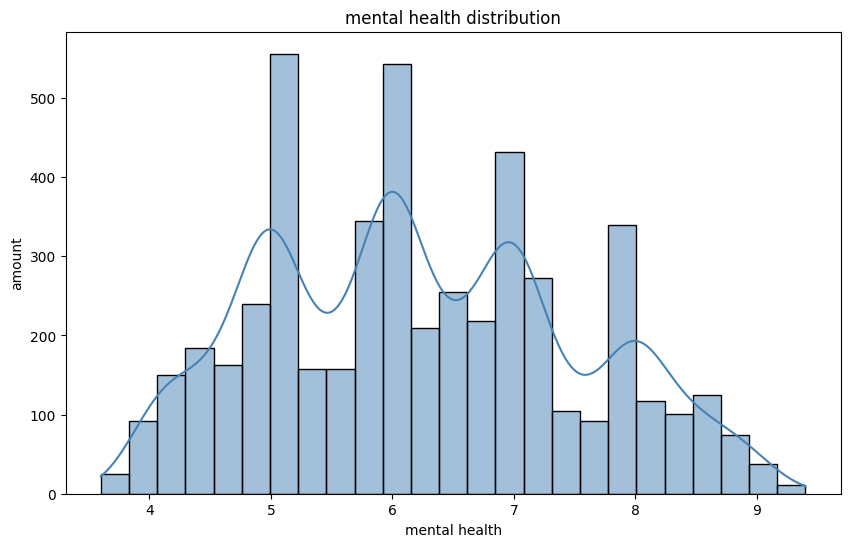

In [12]:
# the distribution of target 
plt.figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'],kde=True,color='steelblue')
plt.title("mental health distribution")
plt.xlabel("mental health")
plt.ylabel("amount")
plt.show()




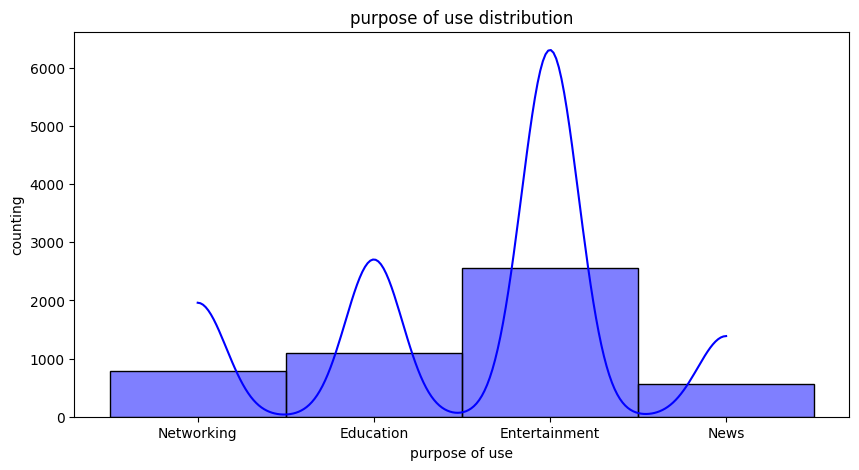

In [13]:
# perpose of use distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Purpose_Of_Use'],kde=True,color='blue')
plt.title("purpose of use distribution")
plt.xlabel("purpose of use")
plt.ylabel("counting")
plt.show()

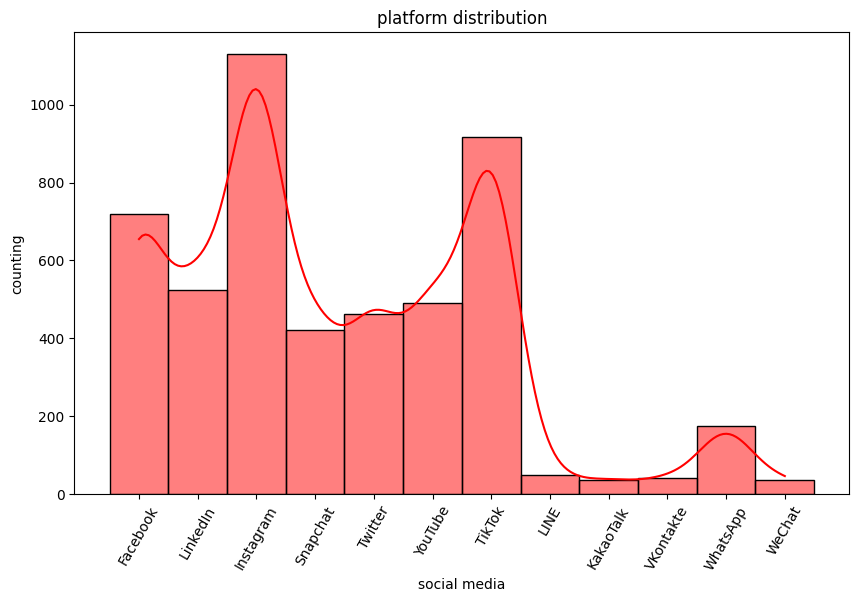

In [14]:
#most used platform distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Most_Used_Platform'],kde=True,color='red')
plt.title("platform distribution")
plt.xlabel("social media")
plt.ylabel("counting")
plt.xticks(rotation=60)
plt.show()

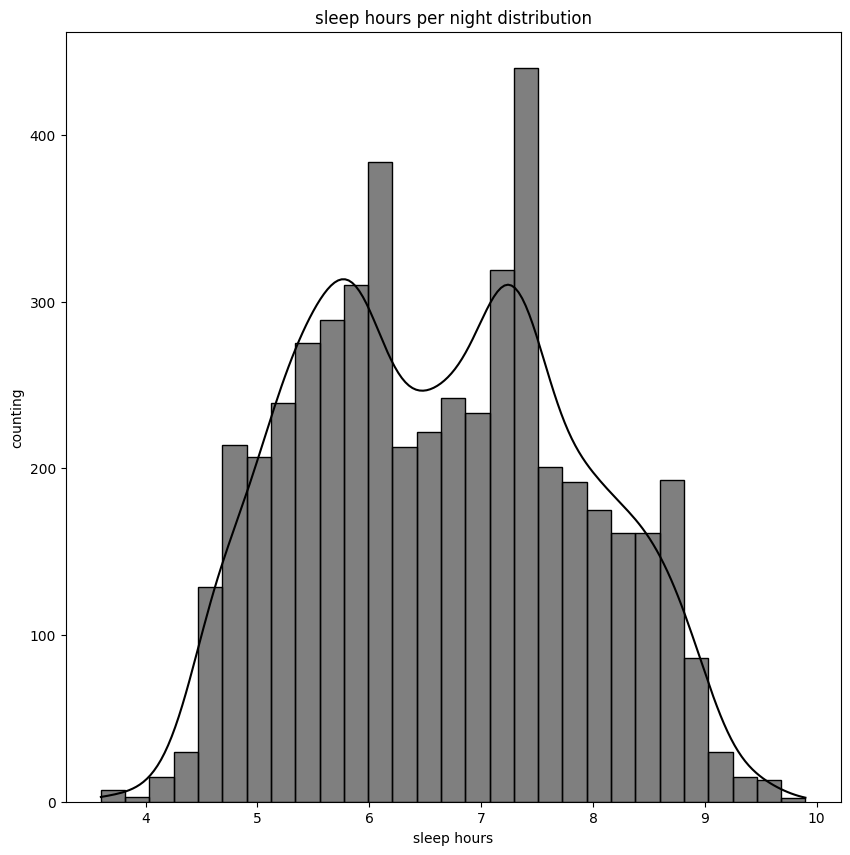

In [15]:
plt.figure(figsize=(10,10))
sns.histplot(df['Sleep_Hours_Per_Night'],kde=True,color='black')
plt.title("sleep hours per night distribution")
plt.xlabel("sleep hours")
plt.ylabel("counting")
plt.show()

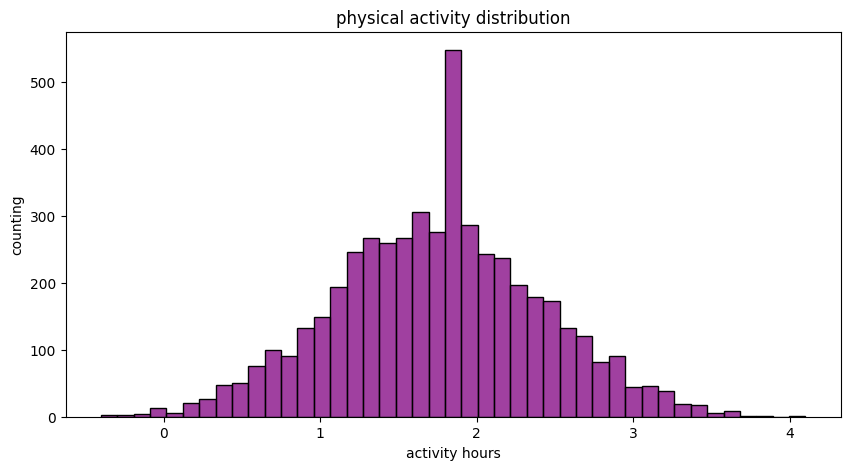

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['Physical_Activity_Hours'],color='purple')
plt.title("physical activity distribution")
plt.xlabel("activity hours")
plt.ylabel("counting")
plt.show()

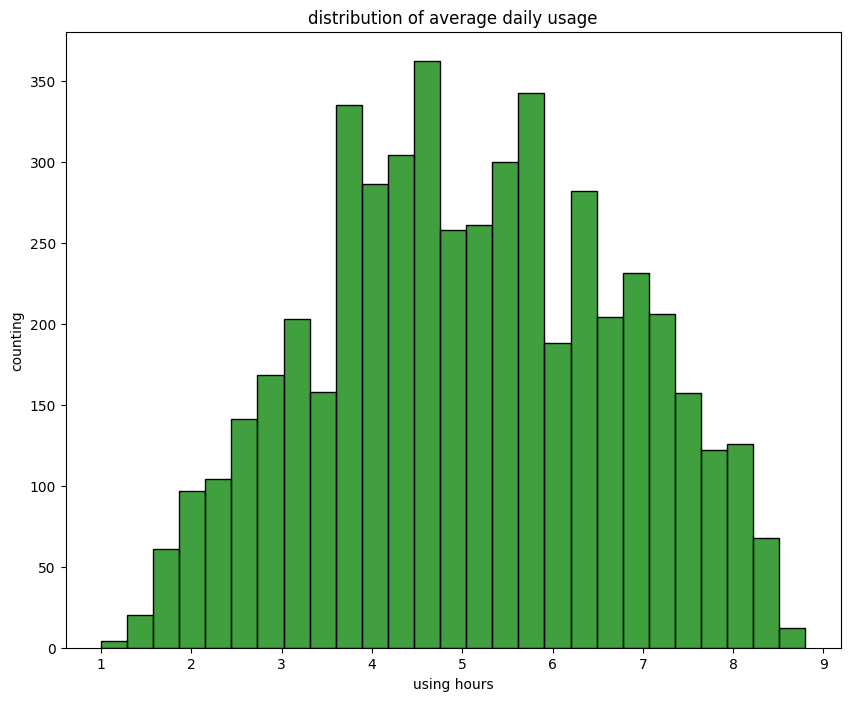

In [17]:
# average daily distribution hours 
   
plt.figure(figsize=(10,8))
sns.histplot(df['Avg_Daily_Usage_Hours'],color='green')
plt.title("distribution of average daily usage")
plt.xlabel('using hours')
plt.ylabel('counting')
plt.show()

Text(0.5, 1.0, 'relation of mental health & age')

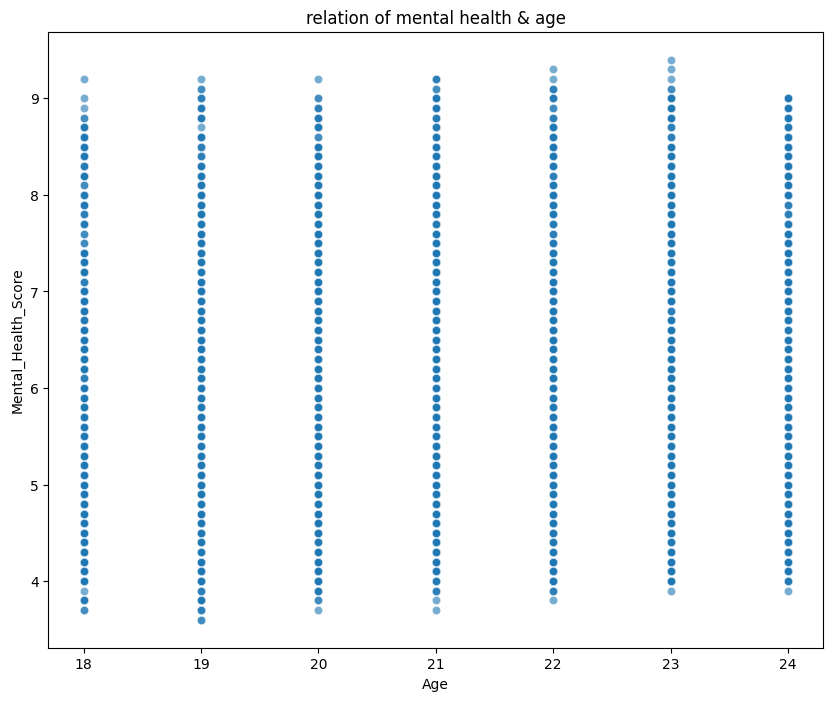

In [18]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Age',y='Mental_Health_Score',alpha=0.6)
plt.title("relation of mental health & age")

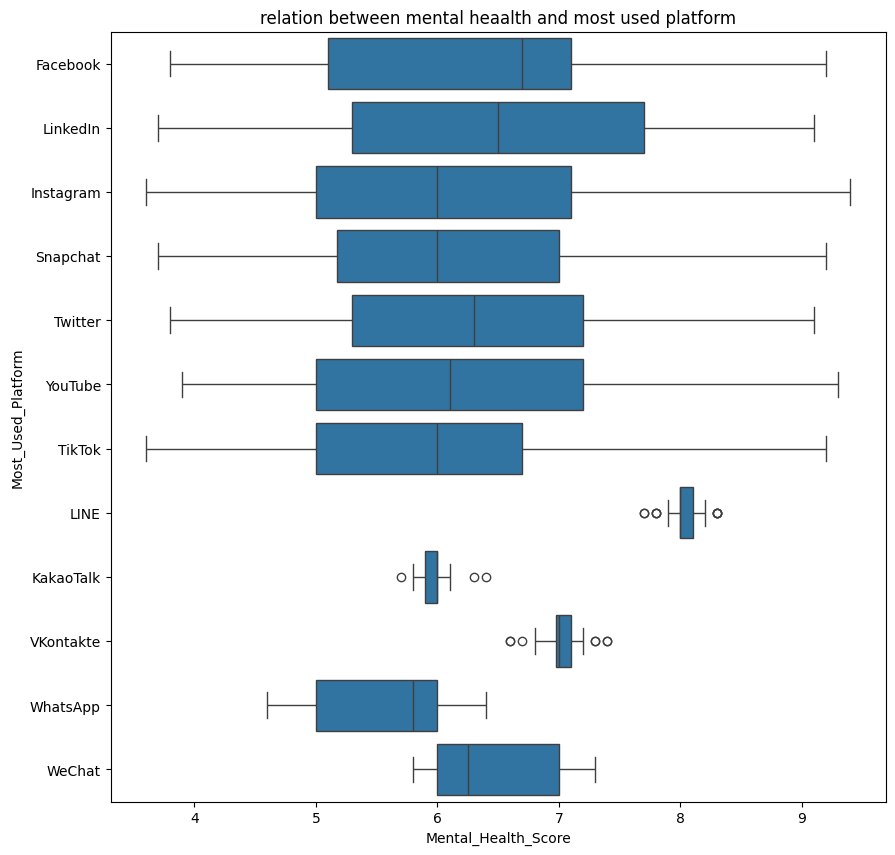

In [19]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df,x='Mental_Health_Score',y='Most_Used_Platform')
plt.title("relation between mental heaalth and most used platform")
plt.show()

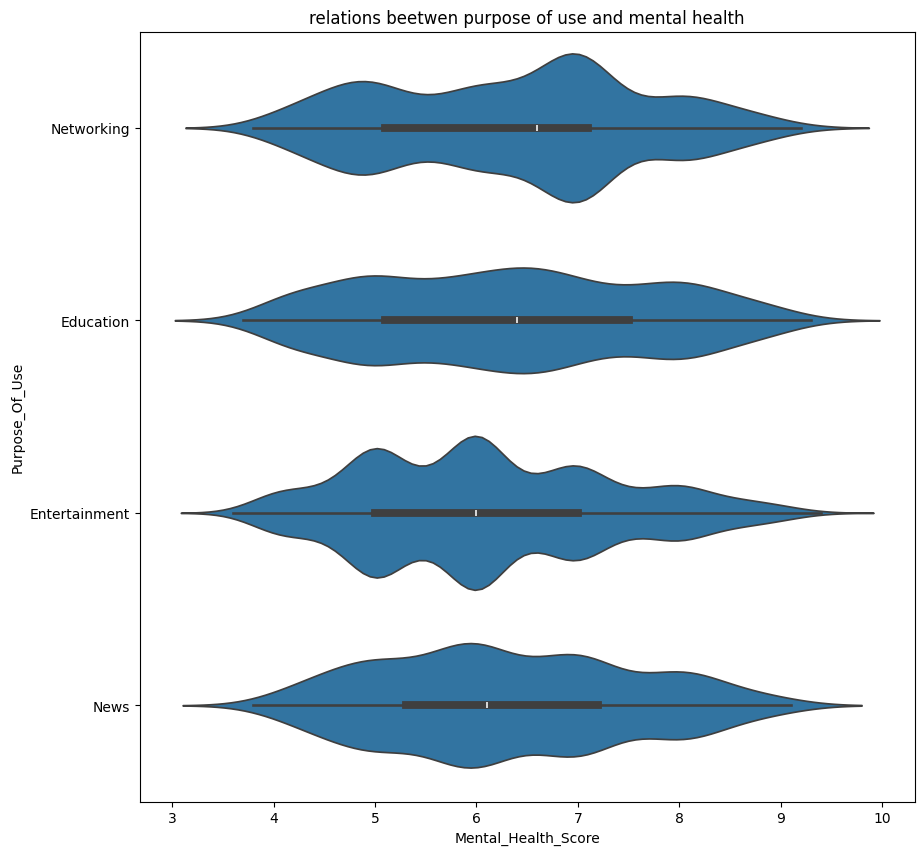

In [20]:
plt.figure(figsize=(10,10))
sns.violinplot(data=df,x='Mental_Health_Score',y='Purpose_Of_Use')
plt.title("relations beetwen purpose of use and mental health")
plt.show()

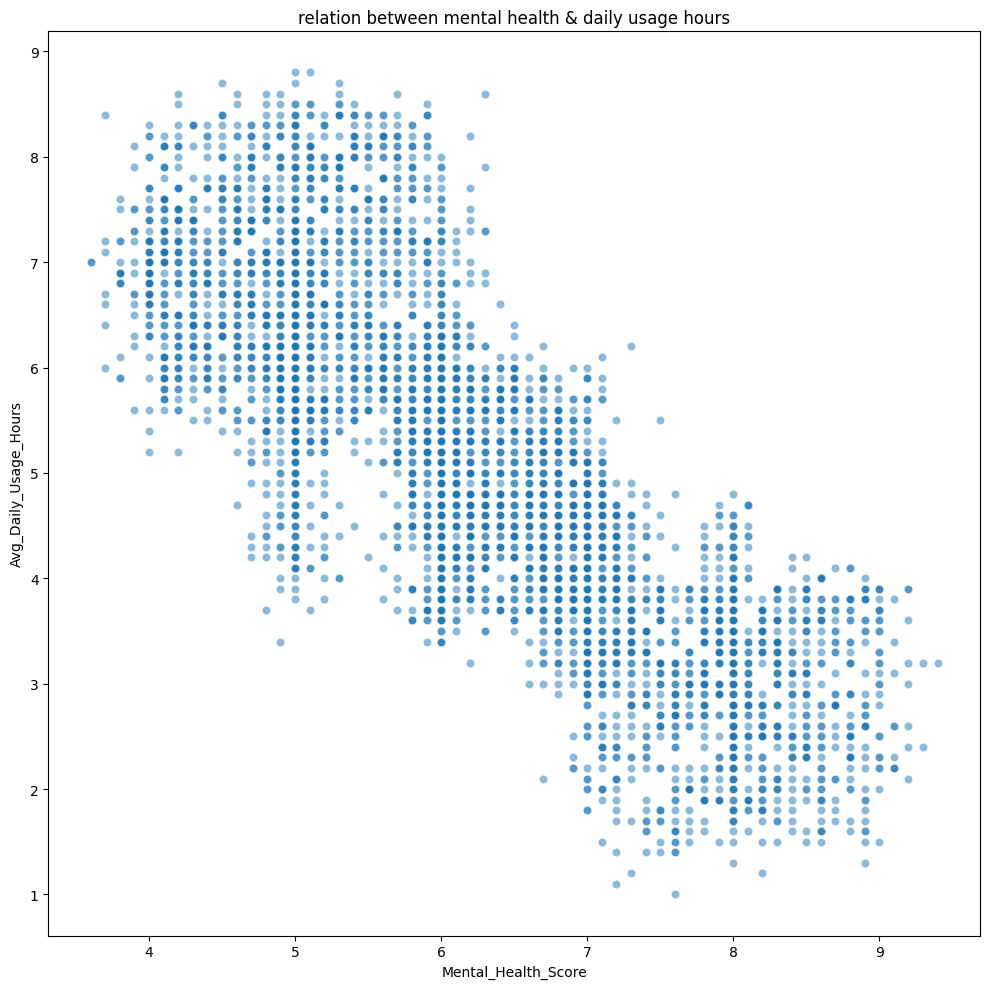

In [21]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x='Mental_Health_Score',y='Avg_Daily_Usage_Hours',alpha=0.5)
plt.title("relation between mental health & daily usage hours")
plt.tight_layout()
plt.show()

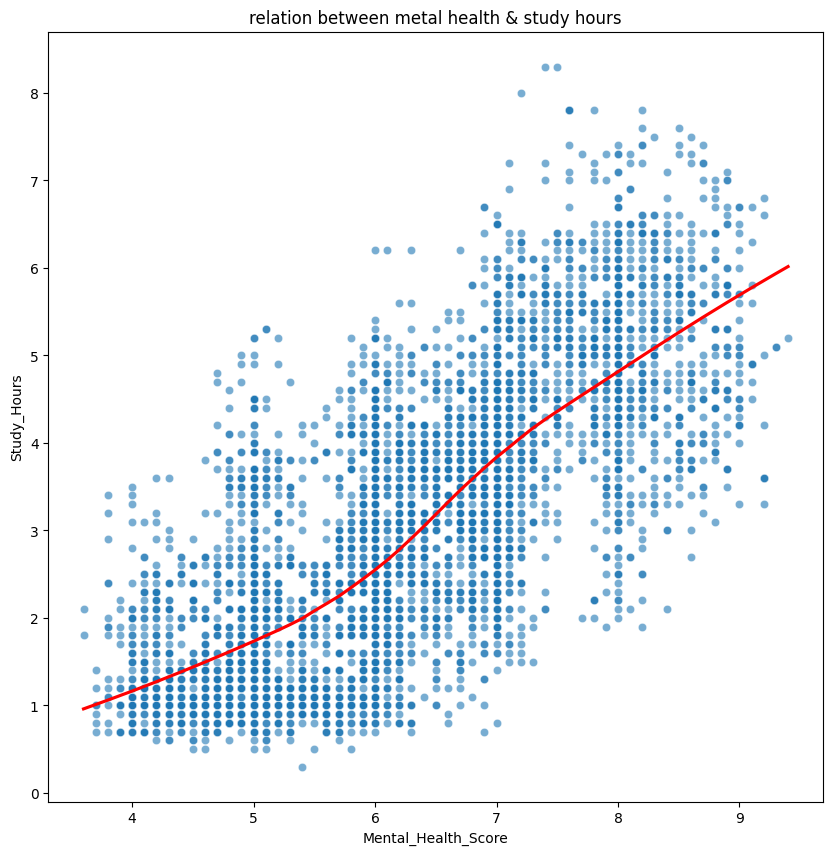

In [22]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x='Mental_Health_Score',y='Study_Hours',alpha=0.6)
sns.regplot(data=df,x='Mental_Health_Score',y='Study_Hours',scatter=False,lowess=True,color='red')
plt.title("relation between metal health & study hours")
plt.show()

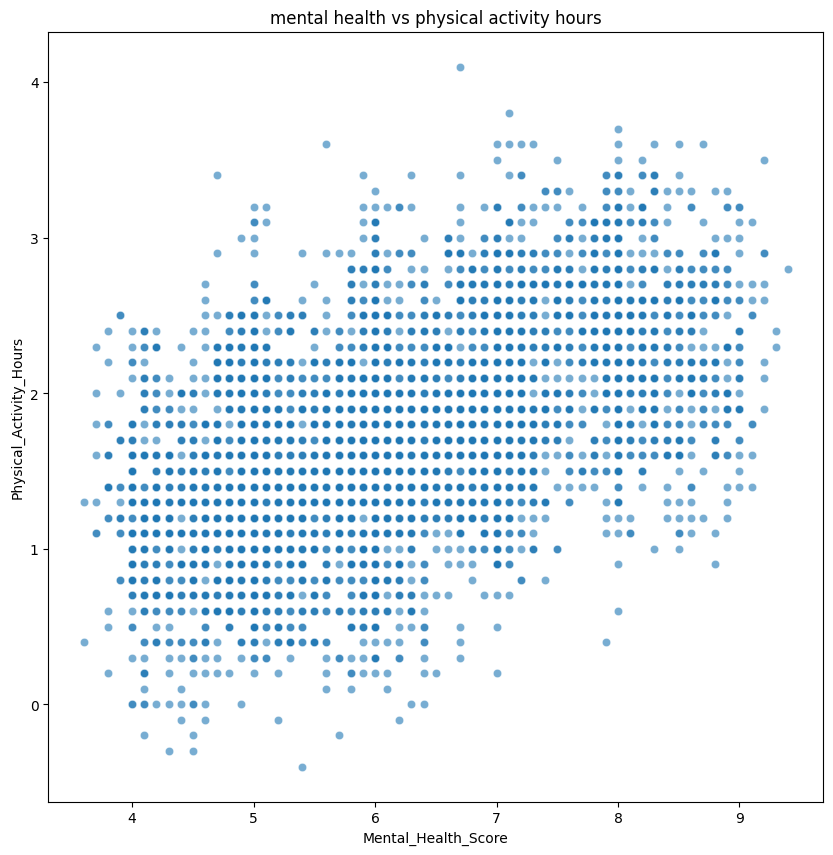

In [23]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x='Mental_Health_Score',y='Physical_Activity_Hours',alpha=0.6)
plt.title('mental health vs physical activity hours')
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


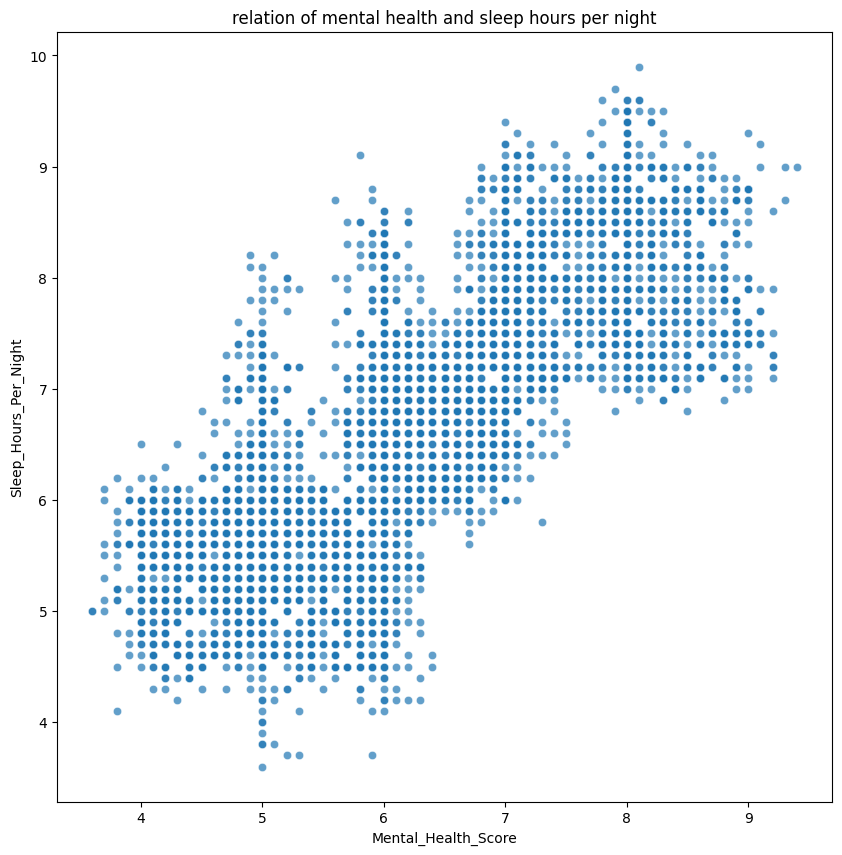

In [25]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df,x='Mental_Health_Score',y='Sleep_Hours_Per_Night',alpha=0.7)
plt.title("relation of mental health and sleep hours per night")
plt.show()

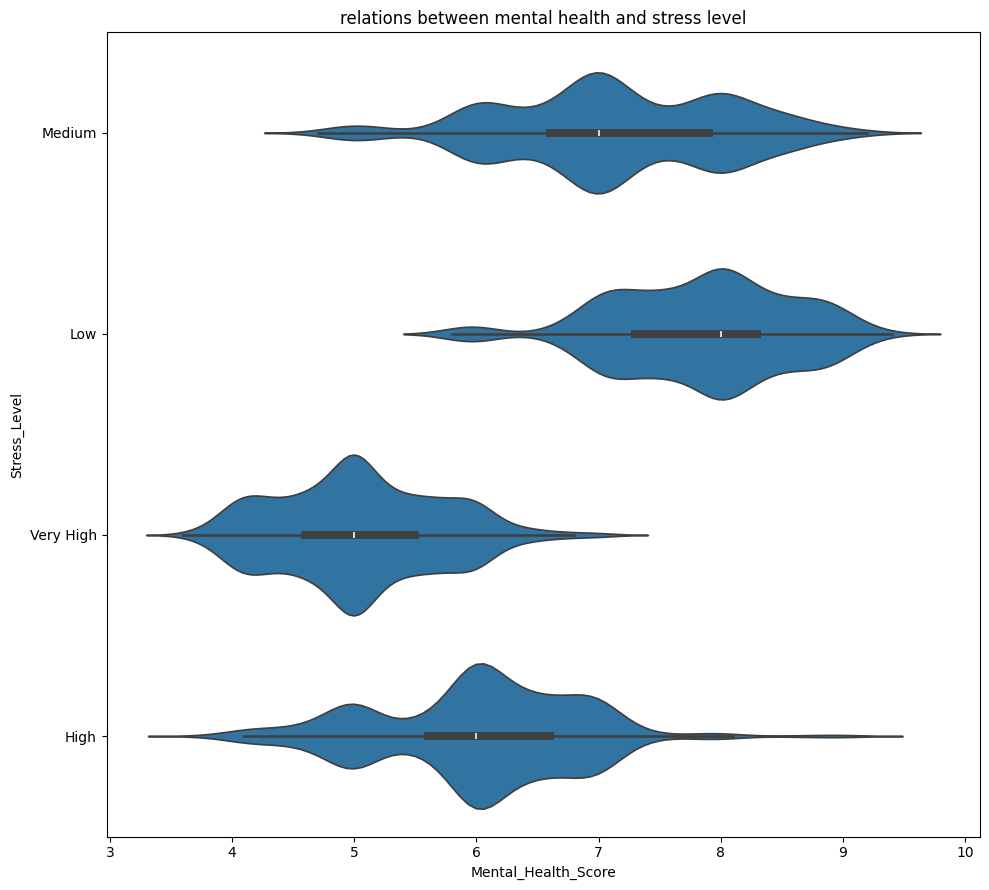

In [26]:
plt.figure(figsize=(10,9))
sns.violinplot(data=df,x='Mental_Health_Score',y='Stress_Level')
plt.title("relations between mental health and stress level")
plt.tight_layout()
plt.show()

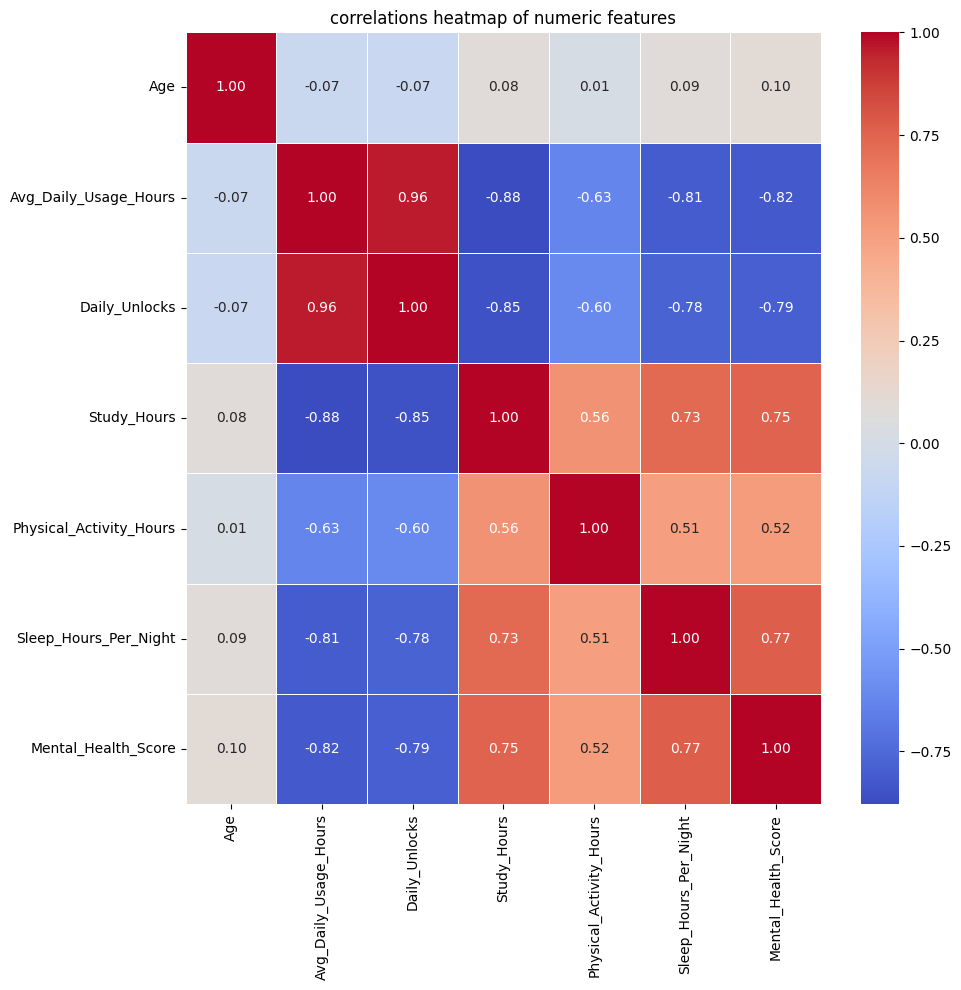

In [27]:
corr=df.select_dtypes("number").corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("correlations heatmap of numeric features")
plt.tight_layout()
plt.show()

# Feature engineering

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [29]:
target='Mental_Health_Score'
X=df.drop(columns=[target])
y=df[target]

catagoric=X.select_dtypes(include=["object","category"]).columns

numeric=X.select_dtypes(exclude=["object","category"]).columns

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

preprocess=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),catagoric),
        ("num",StandardScaler(),numeric)
    ],
    
    remainder="drop"

)

X_train_p=preprocess.fit_transform(X_train)
X_test_p=preprocess.transform(X_test)
    






    




# model training

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
model=LinearRegression()
model.fit(X_train_p, y_train)
pred=model.predict(X_test_p)